In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 1: Importing Required Libraries

We begin by importing all the necessary libraries for data loading, preprocessing, model building, and evaluation.

In [12]:
import os                                          # Directory and path utilities
import random                                     # Random sampling for augmentation
import numpy as np                                # Array and matrix operations
from PIL import Image, ImageEnhance               # Image loading and enhancement
import matplotlib.pyplot as plt                   # Plotting and visualization
import seaborn as sns                             # Statistical plots (confusion matrix)

from sklearn.utils import shuffle                 # Shuffling dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16

## Step 2: Loading the MRI Dataset

The dataset is organised into `Training` and `Testing` folders, each containing sub-folders named after the tumour class. We iterate through these directories to collect image paths and their corresponding labels.

In [13]:
# Root directories for training and testing splits
TRAIN_DIR = '/content/drive/MyDrive/MRI IMages/Training/'
TEST_DIR  = '/content/drive/MyDrive/MRI IMages/Testing/'

# Collect all training image paths and labels
train_paths, train_labels = [], []
for category in os.listdir(TRAIN_DIR):
    category_path = os.path.join(TRAIN_DIR, category)
    for img_file in os.listdir(category_path):
        train_paths.append(os.path.join(category_path, img_file))
        train_labels.append(category)

# Collect all test image paths and labels
test_paths, test_labels = [], []
for category in os.listdir(TEST_DIR):
    category_path = os.path.join(TEST_DIR, category)
    for img_file in os.listdir(category_path):
        test_paths.append(os.path.join(category_path, img_file))
        test_labels.append(category)

# Shuffle both sets to remove any ordering bias
train_paths, train_labels = shuffle(train_paths, train_labels)
test_paths,  test_labels  = shuffle(test_paths,  test_labels)

print(f"Training samples : {len(train_paths)}")
print(f"Testing  samples : {len(test_paths)}")

Training samples : 5712
Testing  samples : 1311


## Step 3: Visualising Sample MRI Scans

Before we start building the model, it is useful to visually inspect a random selection of training images along with their class labels.

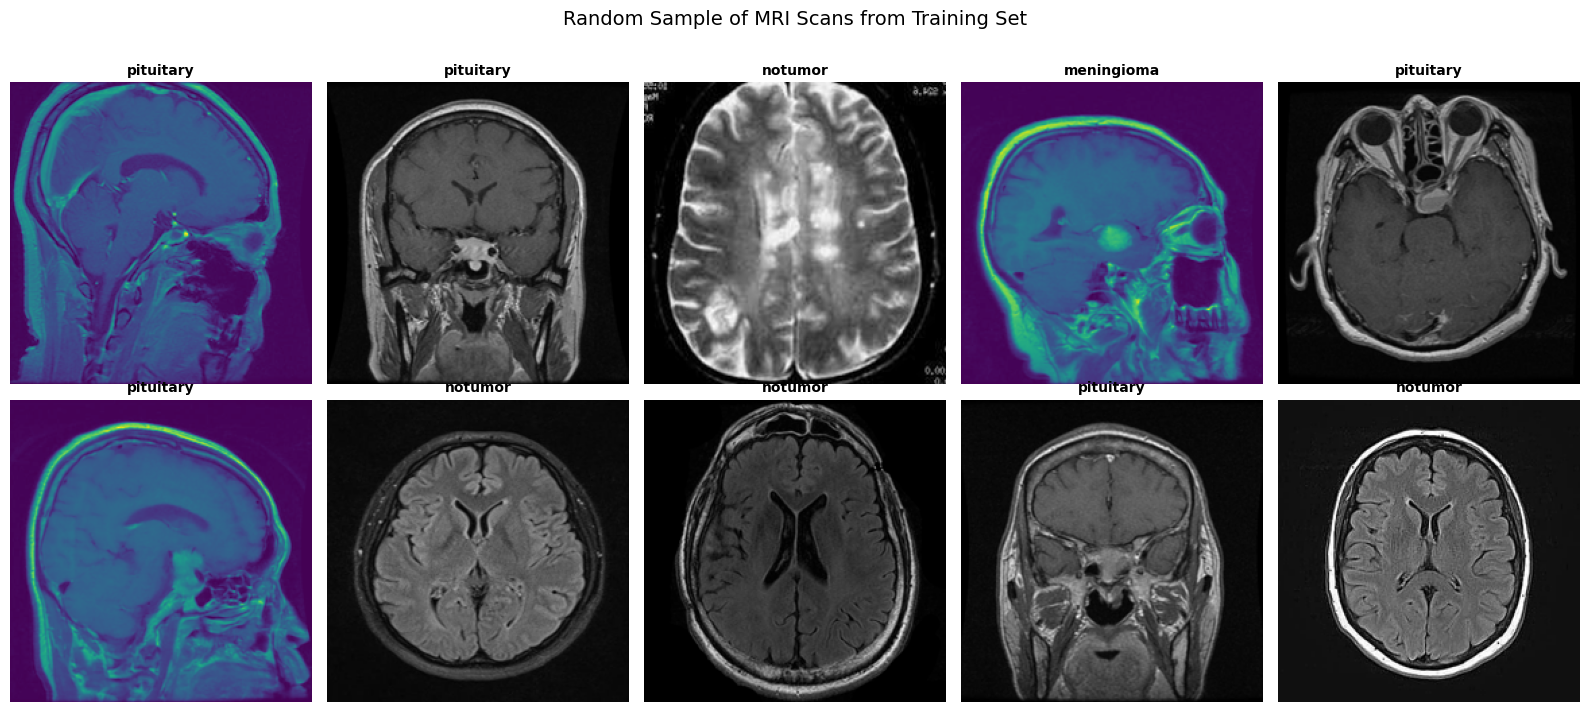

In [14]:
# Pick 10 random samples from the training set
sample_indices = random.sample(range(len(train_paths)), 10)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.ravel()

for i, idx in enumerate(sample_indices):
    img = Image.open(train_paths[idx]).resize((224, 224))
    axes[i].imshow(img)
    axes[i].set_title(train_labels[idx], fontsize=10, fontweight='bold')
    axes[i].axis('off')

fig.suptitle('Random Sample of MRI Scans from Training Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 4: Preprocessing & Data Augmentation Helpers

To improve generalisation, we apply light augmentation (random brightness and contrast jitter) to every image before feeding it to the model. The helper functions below handle:
- `apply_augmentation` – random brightness/contrast shift + normalisation
- `load_batch` – loads a batch of images from disk and augments them
- `encode_labels` – converts string class names to integer indices
- `batch_generator` – a Python generator that yields `(images, labels)` batches

In [15]:
IMG_SIZE = 224  # ← was 128, VGG16 requires 224
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))


def apply_augmentation(img_array):
    """Apply random brightness and contrast jitter, then normalise."""
    pil_img = Image.fromarray(np.uint8(img_array))
    pil_img = ImageEnhance.Brightness(pil_img).enhance(random.uniform(0.8, 1.2))
    pil_img = ImageEnhance.Contrast(pil_img).enhance(random.uniform(0.8, 1.2))
    return np.array(pil_img) / 255.0  # Scale to [0, 1]


def load_batch(paths):
    """Load images from a list of file paths and apply augmentation."""
    batch = []
    for p in paths:
        img = load_img(p, target_size=(IMG_SIZE, IMG_SIZE))
        img = apply_augmentation(np.array(img))
        batch.append(img)
    return np.array(batch)


def encode_labels(labels):
    """Map class name strings to integer indices."""
    return np.array([CLASS_NAMES.index(lbl) for lbl in labels])


def batch_generator(paths, labels, batch_size=12, epochs=1):
    """Generator that yields (image_batch, label_batch) for model.fit."""
    for _ in range(epochs):
        for start in range(0, len(paths), batch_size):
            end         = start + batch_size
            img_batch   = load_batch(paths[start:end])
            label_batch = encode_labels(labels[start:end])
            yield img_batch, label_batch

## Step 5: Building the Model with Transfer Learning (VGG16)

We use **VGG16** pre-trained on ImageNet as a feature extractor. The strategy is:

1. Load VGG16 without its top classification head (`include_top=False`).
2. Freeze all base layers so ImageNet weights are preserved.
3. Unfreeze the last three convolutional layers so they can fine-tune on our MRI data.
4. Add a custom classification head: `Flatten → Dropout → Dense(256, relu) → Dropout → Dense(num_classes, softmax)`.

This approach lets us benefit from rich low-level features learned on ImageNet while adapting the higher-level features to brain MRI scans.

In [16]:
NUM_CLASSES = len(CLASS_NAMES)

# Load pre-trained VGG16 without the classification head
vgg_base = VGG16(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all layers initially
for layer in vgg_base.layers:
    layer.trainable = False

# Unfreeze the last three conv layers for fine-tuning
for layer in vgg_base.layers[-4:-1]:
    layer.trainable = True

# Build the full model
model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    vgg_base,
    Flatten(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,500 (80.64 MB)

 Trainable params: 13,503,236 (51.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

## Step 6: Training the Model

In [17]:
BATCH_SIZE = 20
EPOCHS     = 5
steps_per_epoch = int(len(train_paths) / BATCH_SIZE)

history = model.fit(
    batch_generator(train_paths, train_labels, batch_size=BATCH_SIZE, epochs=EPOCHS),
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch
)

Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 2615s 9s/step - loss: 0.4188 - sparse_categorical_accuracy: 0.8442
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 63s 174ms/step - loss: 0.1857 - sparse_categorical_accuracy: 0.9332
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 49s 173ms/step - loss: 0.1055 - sparse_categorical_accuracy: 0.9610
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 49s 173ms/step - loss: 0.0688 - sparse_categorical_accuracy: 0.9758
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 50s 174ms/step - loss: 0.0582 - sparse_categorical_accuracy: 0.9809


## Step 7: Training History — Accuracy & Loss

Let's plot how accuracy and loss evolved across epochs.

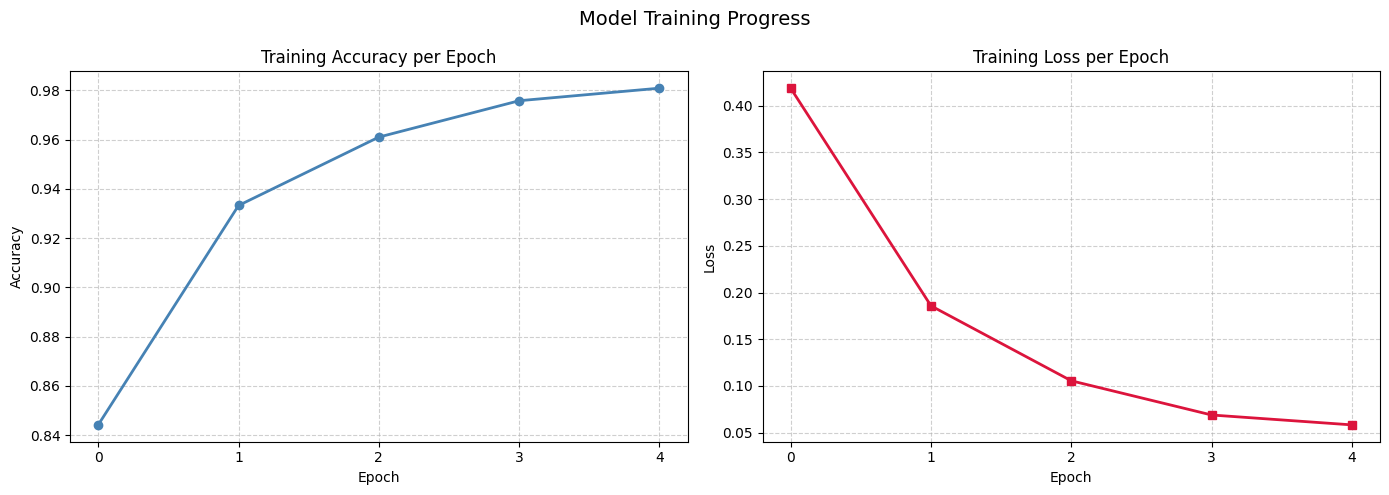

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['sparse_categorical_accuracy'], marker='o', color='steelblue', linewidth=2)
ax1.set_title('Training Accuracy per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(range(EPOCHS))
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(history.history['loss'], marker='s', color='crimson', linewidth=2)
ax2.set_title('Training Loss per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_xticks(range(EPOCHS))
ax2.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Model Training Progress', fontsize=14)
plt.tight_layout()
plt.show()

## Step 8: Evaluating the Model on Test Data

We run the trained model on the held-out test set and generate a full classification report (precision, recall, F1-score per class).

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/MRI IMages/Testing',
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

test_generator.reset()
preds = model.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

print("Classification Report\n" + "="*50)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Found 1311 images belonging to 4 classes.
41/41 ━━━━━━━━━━━━━━━━━━━━ 694s 17s/step
Classification Report
              precision    recall  f1-score   support

      glioma       0.99      0.81      0.89       300
  meningioma       0.82      0.97      0.88       306
     notumor       1.00      0.99      0.99       405
   pituitary       0.97      0.97      0.97       300

    accuracy                           0.94      1311
   macro avg       0.94      0.93      0.93      1311
weighted avg       0.95      0.94      0.94      1311



## Step 9: Confusion Matrix

The confusion matrix shows how well the model distinguishes between each tumour type.

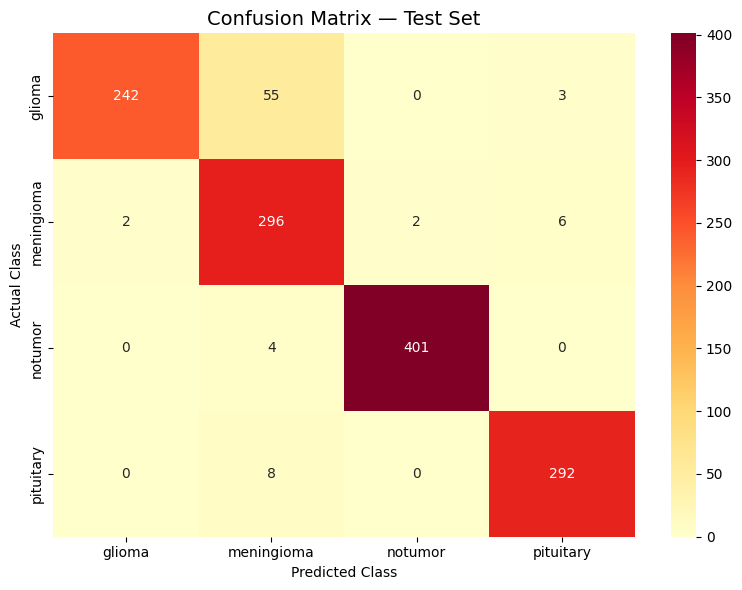

In [21]:
cm = confusion_matrix(y_true, y_pred)  # ← changed variable names

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='YlOrRd',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title('Confusion Matrix — Test Set', fontsize=14)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

## Step 10: ROC Curves (One-vs-Rest)

We binarise the labels and plot an ROC curve for each class using a one-vs-rest strategy. The AUC score tells us how well the model separates each class from the rest.

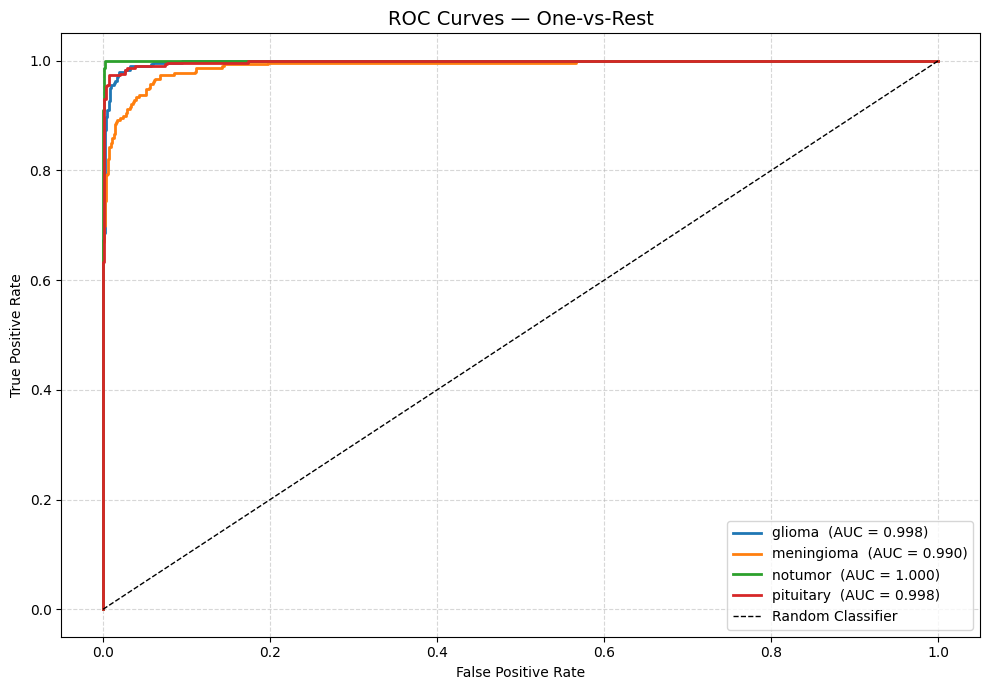

In [24]:
# Binarise labels for multi-class ROC
pred_probs = preds  # ← add this line
labels_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

fpr_dict, tpr_dict, auc_dict = {}, {}, {}
for cls_idx in range(NUM_CLASSES):
    fpr_dict[cls_idx], tpr_dict[cls_idx], _ = roc_curve(labels_bin[:, cls_idx], pred_probs[:, cls_idx])
    auc_dict[cls_idx] = auc(fpr_dict[cls_idx], tpr_dict[cls_idx])

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10.colors
for cls_idx in range(NUM_CLASSES):
    plt.plot(
        fpr_dict[cls_idx], tpr_dict[cls_idx],
        label=f'{CLASS_NAMES[cls_idx]}  (AUC = {auc_dict[cls_idx]:.3f})',
        color=colors[cls_idx], linewidth=2
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.title('ROC Curves — One-vs-Rest', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Step 11: Saving and Loading the Model

We save the trained model to disk so it can be reloaded later without retraining.

In [25]:
import os

# Saves directly to Google Drive — survives session restarts
MODEL_PATH = "/content/drive/MyDrive/MRI IMages/brain_tumor_vgg16.h5"

model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# Sanity check — verify weights are not corrupted
from tensorflow.keras.models import load_model
import numpy as np

verify = load_model(MODEL_PATH)
blank = np.zeros((1, 224, 224, 3))
p = verify.predict(blank)[0]
print("\nSanity check (should be ~25% each):")
for cls, prob in zip(['glioma', 'meningioma', 'notumor', 'pituitary'], p):
    print(f"  {cls}: {prob*100:.2f}%")

Model saved to: /content/drive/MyDrive/MRI IMages/brain_tumor_vgg16.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step

Sanity check (should be ~25% each):
  glioma: 37.42%
  meningioma: 32.59%
  notumor: 21.80%
  pituitary: 8.19%


In [26]:
import os

# Saves directly to Google Drive — survives session restarts
MODEL_PATH = "/content/drive/MyDrive/brain_tumor_vgg16.h5"

model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# Sanity check — verify weights are not corrupted
from tensorflow.keras.models import load_model
import numpy as np

verify = load_model(MODEL_PATH)
blank = np.zeros((1, 224, 224, 3))
p = verify.predict(blank)[0]
print("\nSanity check (should be ~25% each):")
for cls, prob in zip(['glioma', 'meningioma', 'notumor', 'pituitary'], p):
    print(f"  {cls}: {prob*100:.2f}%")

Model saved to: /content/drive/MyDrive/brain_tumor_vgg16.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Sanity check (should be ~25% each):
  glioma: 37.42%
  meningioma: 32.59%
  notumor: 21.80%
  pituitary: 8.19%


## Step 12: Single-Image Inference — Tumour Detection

The function below accepts any MRI scan path, runs it through the model, and displays the predicted diagnosis along with a confidence score. If the model predicts `notumor`, a clean result is shown; otherwise the specific tumour type is reported.

In [33]:
LABELS = ['glioma', 'meningioma', 'notumor', 'pituitary']  # Must match training order

def run_inference(img_path, trained_model, img_size=224):  # ← 128 to 224
    """
    Run the model on a single MRI scan and display the prediction.

    Parameters
    ----------
    img_path      : str  — path to the MRI image file
    trained_model : keras Model
    img_size      : int  — target resize dimension (must match training size)
    """
    try:
        # Load and preprocess
        raw_img   = load_img(img_path, target_size=(img_size, img_size))
        img_arr   = img_to_array(raw_img) / 255.0
        img_arr   = np.expand_dims(img_arr, axis=0)

        # Predict
        probs        = trained_model.predict(img_arr, verbose=0)
        top_idx      = int(np.argmax(probs))
        confidence   = float(np.max(probs)) * 100
        diagnosis    = 'No Tumour Detected' if LABELS[top_idx] == 'notumor' \
                       else f'Tumour Detected: {LABELS[top_idx].capitalize()}'

        # Display
        plt.figure(figsize=(5, 5))
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f'{diagnosis}\nConfidence: {confidence:.2f}%', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    except Exception as err:
        print(f'[Error] Could not process image: {err}')

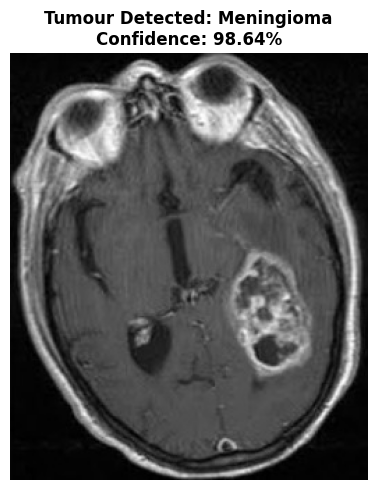

In [34]:
img_path = '/content/drive/MyDrive/MRI IMages/Testing/meningioma/Te-meTr_0001.jpg'
run_inference(img_path, model)

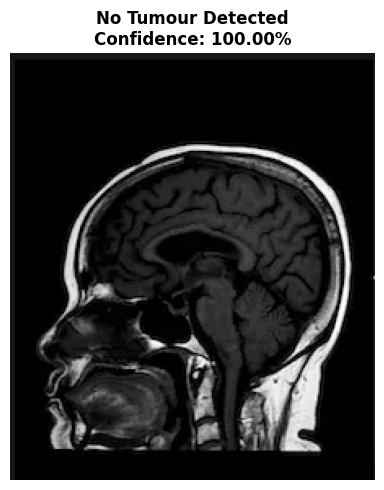

In [35]:
img_path = '/content/drive/MyDrive/MRI IMages/Testing/notumor/Te-noTr_0004.jpg'
run_inference(img_path, model)

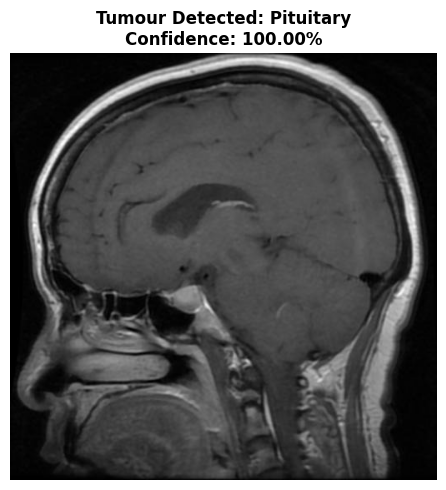

In [36]:
img_path = '/content/drive/MyDrive/MRI IMages/Testing/pituitary/Te-piTr_0003.jpg'
run_inference(img_path, model)

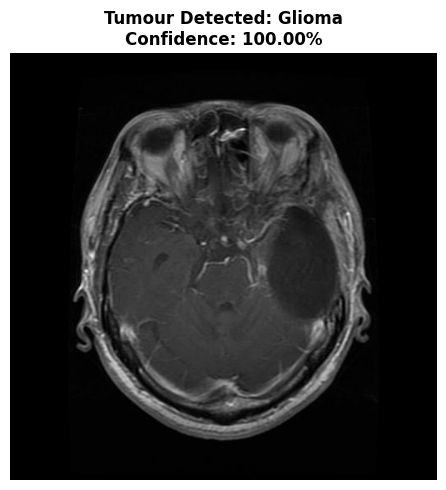

In [37]:
img_path = '/content/drive/MyDrive/MRI IMages/Testing/glioma/Te-gl_0015.jpg'
run_inference(img_path, model)